In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,Passenger 1,male,20.3,0,2,TKT00001,186.46,D33,S
1,2,1,1,Passenger 2,female,18.3,0,2,TKT00002,53.72,A10,Q
2,3,1,3,Passenger 3,female,23.0,1,2,TKT00003,108.54,E46,S
3,4,0,2,Passenger 4,male,9.1,2,1,TKT00004,152.91,NaN,S
4,5,1,2,Passenger 5,female,7.2,2,2,TKT00005,52.11,NaN,S


In [5]:
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          799 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        632 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             92
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          259
Embarked         0
dtype: int64

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [9]:
df.drop(columns=["Cabin"], inplace=True)

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [11]:
df.drop_duplicates(inplace=True)

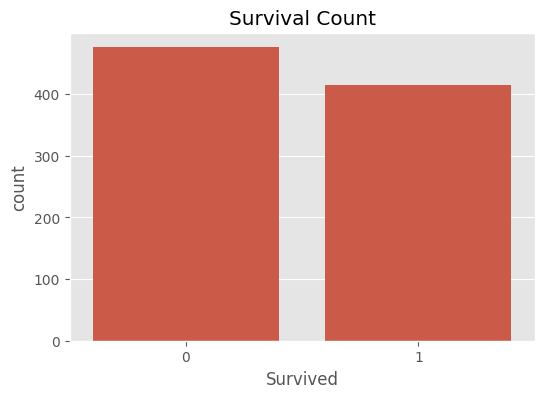

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.savefig("images/survival_count.png")
plt.show()

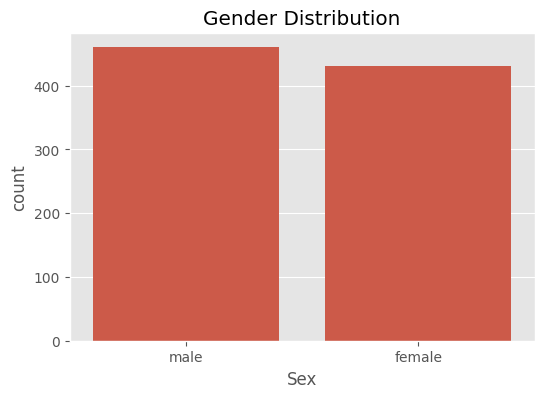

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.savefig("images/gender_distribution.png")
plt.show()

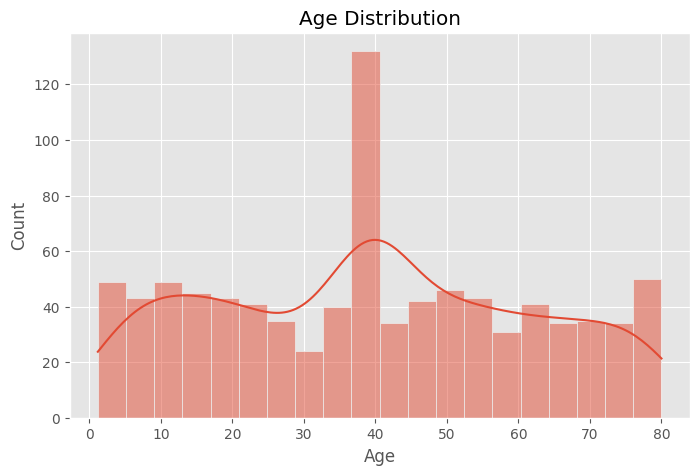

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.savefig("images/age_distribution.png")
plt.show()

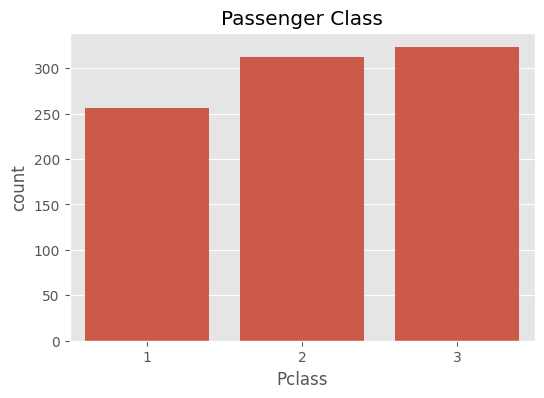

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class")
plt.savefig("images/passenger_class.png")
plt.show()

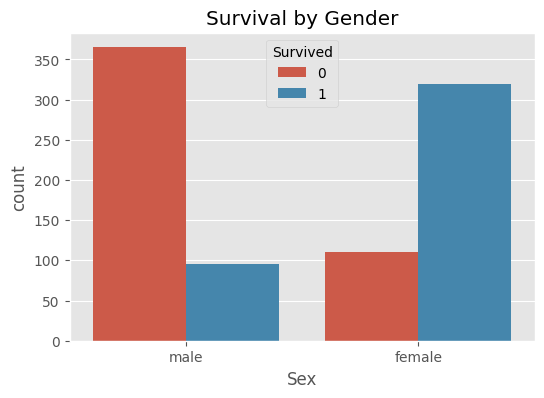

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.savefig("images/gender_survival.png")
plt.show()

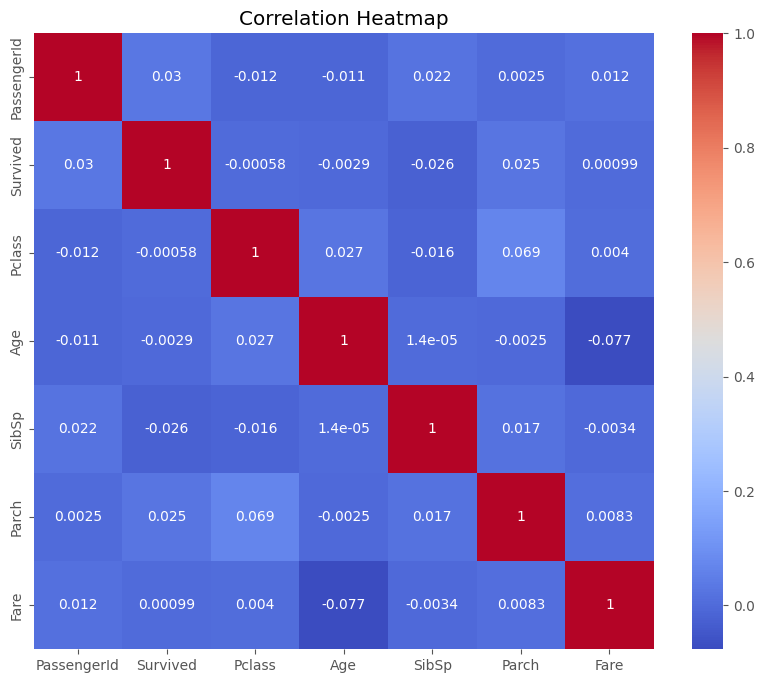

In [ ]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png")
plt.show()

In [ ]:
df.to_csv("data/cleaned_train.csv", index=False)